## Setup i wczytanie danych

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff

source = arff.loadarff('Dry_Bean_Dataset.arff')
df = pd.DataFrame(source[0])
df['Class'] = df['Class'].str.decode('utf-8')

print(df.shape)
print(df['Class'].value_counts())
df.describe().T[['mean', 'std', 'min', 'max']]

(13611, 17)
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


,mean,std,min,max
Area,53048.284549,29324.095717,20420.000000,254616.000000
Perimeter,855.283459,214.289696,524.736000,1985.370000
MajorAxisLength,320.141867,85.694186,183.601165,738.860153
MinorAxisLength,202.270714,44.970091,122.512653,460.198497
AspectRation,1.583242,0.246678,1.024868,2.430306
Eccentricity,0.750895,0.092002,0.218951,0.911423
ConvexArea,53768.200206,29774.915817,20684.000000,263261.000000
EquivDiameter,253.064220,59.177120,161.243764,569.374358
Extent,0.749733,0.049086,0.555315,0.866195
Solidity,0.987143,0.004660,0.919246,0.994677


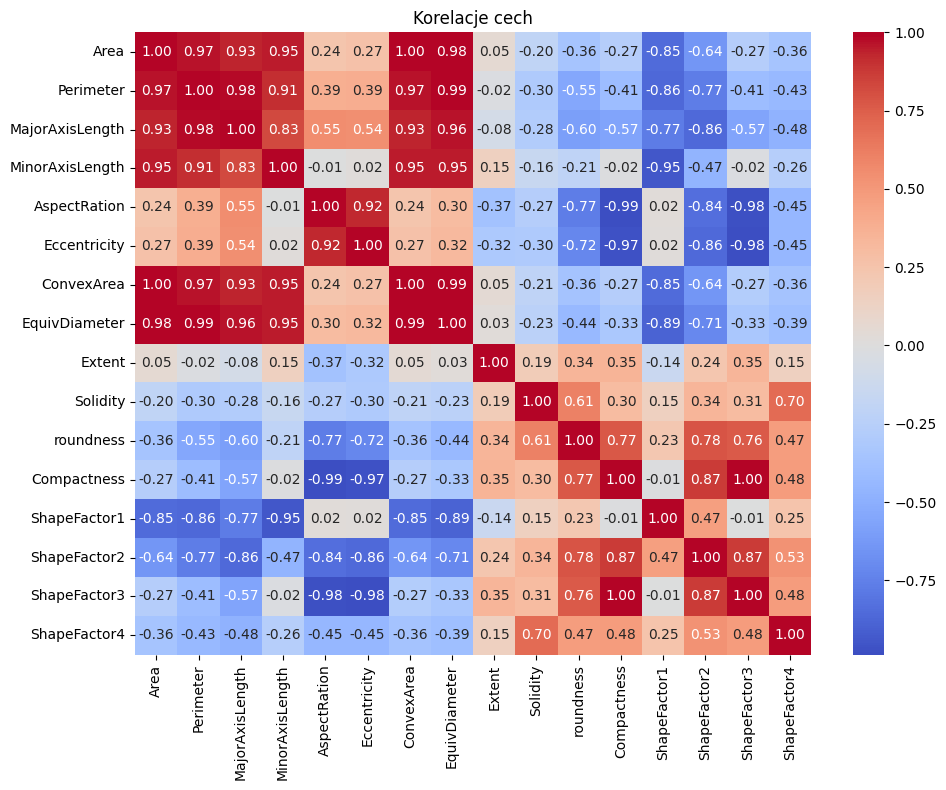

In [2]:
X = df.drop(columns='Class')

plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelacje cech')
plt.tight_layout()
plt.show()

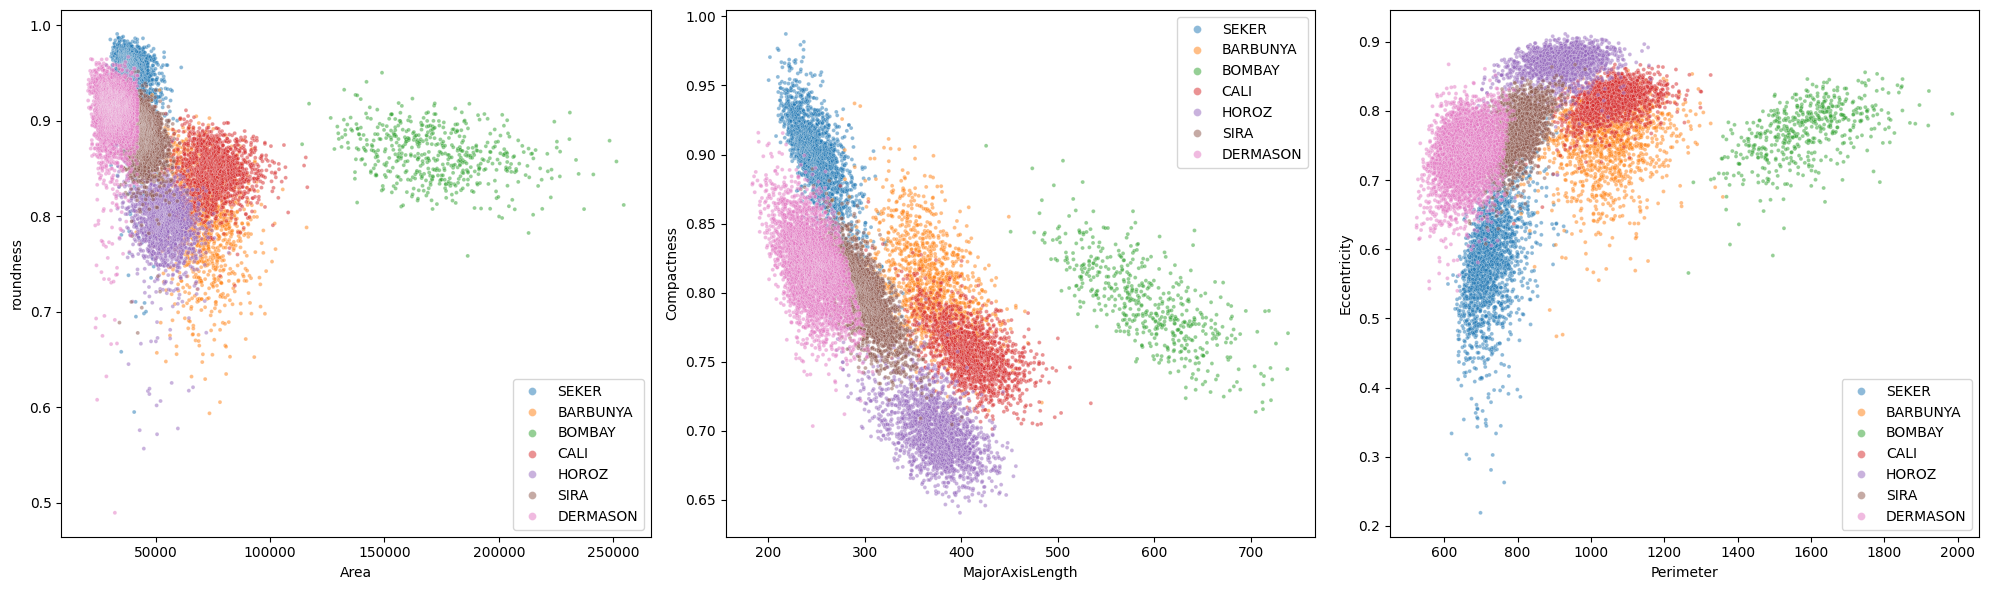

In [19]:
pairs = [('Area', 'roundness'), ('MajorAxisLength', 'Compactness'),
         ('Perimeter', 'Eccentricity')]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (a, b) in zip(axes, pairs):
    sns.scatterplot(data=df, x=a, y=b, hue='Class', s=8, alpha=0.5, ax=ax)
    ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

Cechy mają bardzo różną skalę (Area w dziesiątkach tysięcy, ShapeFactor2 w tysięcznych), więc trzeba je standaryzować.

Niektóre cechy są praktycznie tym samym (Area i ConvexArea, Compactness i ShapeFactor3 mają korelację 1.00), więc wyrzucam duplikaty: ConvexArea, EquivDiameter i ShapeFactor3.

Na wykresach BOMBAY jest wyraźnie osobno, a reszta gatunków zlewa się w jedną grupę. Zapowiada to, że ten jeden gatunek będzie łatwy do oddzielenia, a pozostałe cięższe.

## KMeans

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

drop_cols = ['ConvexArea', 'EquivDiameter', 'ShapeFactor3']
X = df.drop(columns=['Class'] + drop_cols)
y_true = df['Class'].values

X_scaled = StandardScaler().fit_transform(X)

km = KMeans(n_clusters=7, n_init=10, random_state=42).fit(X_scaled)
print(f'Inercja: {km.inertia_:.1f}')

Inercja: 44141.5


Wyjaśniona wariancja: 78.49%


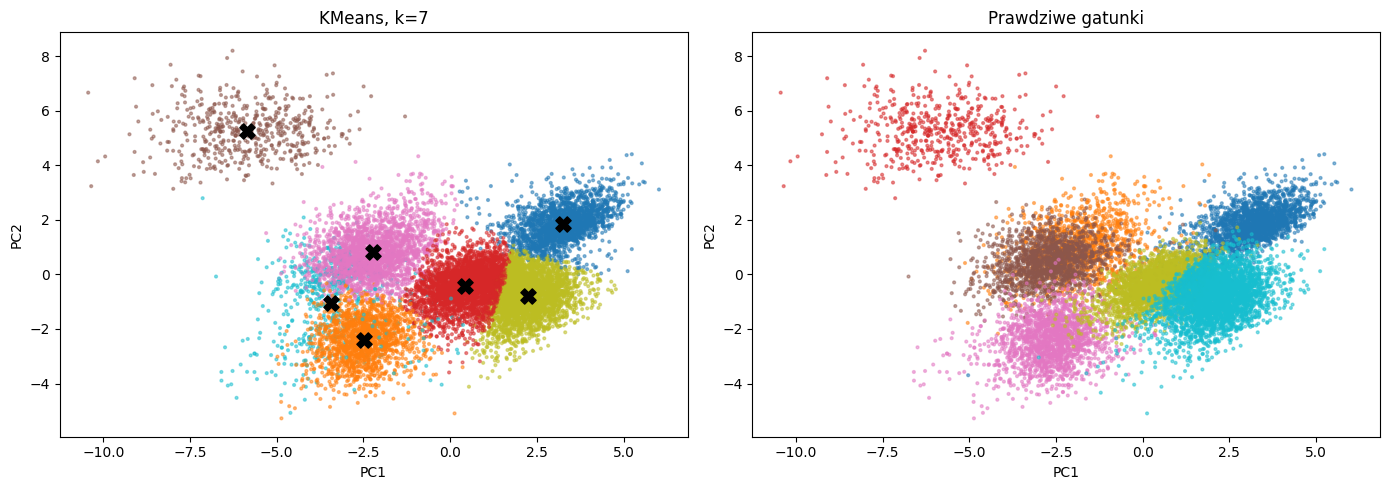

In [5]:
pca = PCA(n_components=2, random_state=42).fit(X_scaled)
X_2d = pca.transform(X_scaled)
print(f'Wyjaśniona wariancja: {pca.explained_variance_ratio_.sum():.2%}')

def show_clustering(labels, title, centers=None, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', s=4, alpha=0.5)
    if centers is not None:
        c2d = pca.transform(centers)
        ax.scatter(c2d[:, 0], c2d[:, 1], c='black', marker='X', s=120)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
show_clustering(km.labels_, 'KMeans, k=7', centers=km.cluster_centers_, ax=axes[0])
show_clustering(pd.factorize(y_true)[0], 'Prawdziwe gatunki', ax=axes[1])
plt.tight_layout()
plt.show()

     k     inertia  silhouette  purity
0    2  106812.772       0.386   0.399
1    3   82996.758       0.393   0.435
2    4   68249.557       0.324   0.554
3    5   56233.532       0.339   0.662
4    6   49258.824       0.344   0.653
5    7   44141.535       0.294   0.795
6    8   40806.844       0.291   0.792
7    9   37730.469       0.295   0.868
8   10   35535.517       0.288   0.850
9   11   33644.528       0.288   0.852
10  12   32175.008       0.260   0.845
11  13   31083.765       0.261   0.855
12  14   30127.880       0.239   0.864
13  15   29250.088       0.251   0.860


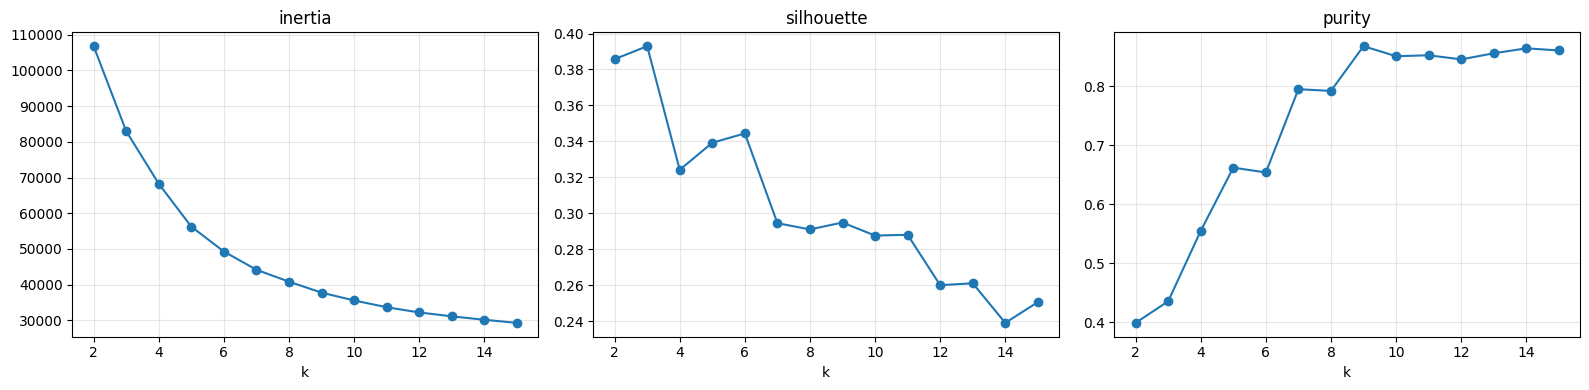

In [6]:
from sklearn.metrics.cluster import contingency_matrix
from sklearn.metrics import silhouette_score

def purity_score(labels_true, labels_pred):
    cont_matrix = contingency_matrix(labels_true, labels_pred)
    return np.max(cont_matrix, axis=0).sum() / cont_matrix.sum()

ks = range(2, 16)
results = []

for k in ks:
    km_k = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    results.append({
        'k': k,
        'inertia': km_k.inertia_,
        'silhouette': silhouette_score(X_scaled, km_k.labels_),
        'purity': purity_score(y_true, km_k.labels_),
    })

res = pd.DataFrame(results)
print(res.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['inertia', 'silhouette', 'purity']):
    ax.plot(res['k'], res[col], marker='o')
    ax.set_xlabel('k')
    ax.set_title(col)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

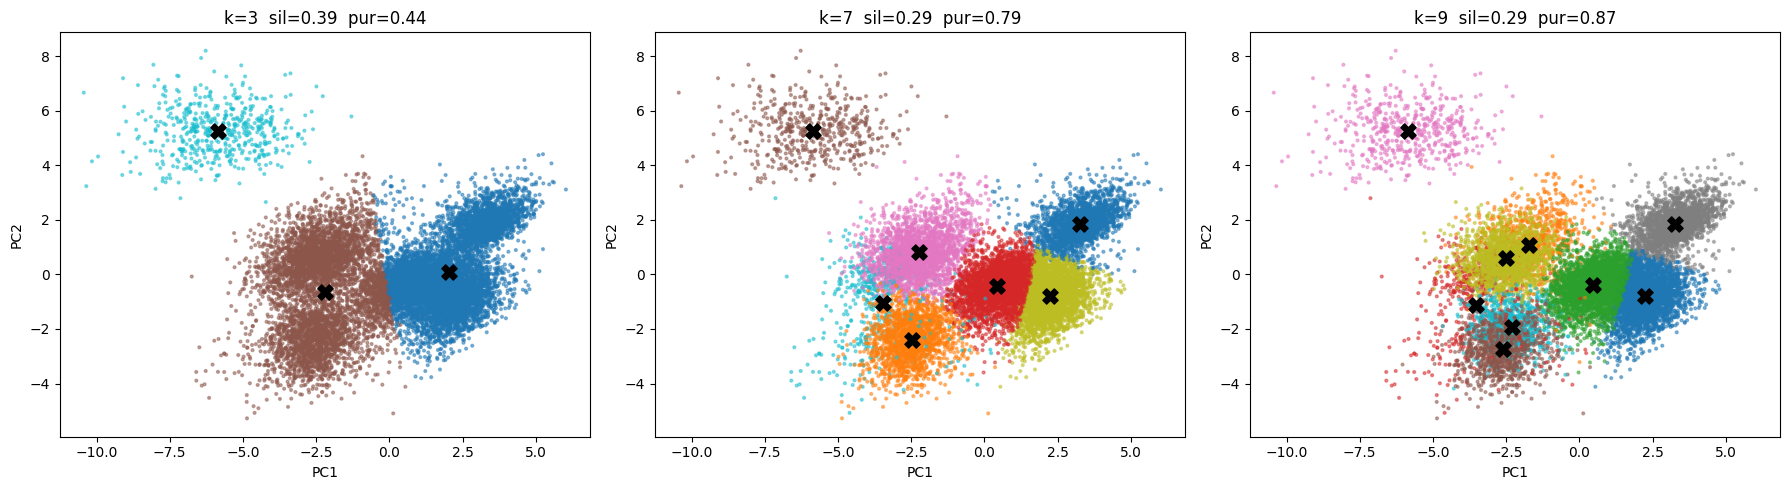

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, k in zip(axes, [3, 7, 9]):
    km_k = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    sil = silhouette_score(X_scaled, km_k.labels_)
    pur = purity_score(y_true, km_k.labels_)
    show_clustering(km_k.labels_, f'k={k}  sil={sil:.2f}  pur={pur:.2f}',
                    centers=km_k.cluster_centers_, ax=ax)
plt.tight_layout()
plt.show()

## Wnioski z KMeans

KMeans sprawdzony dla k od 2 do 15. Silhouette jest najwyższe przy k=2 i k=3, bo tylko BOMBAY jest osobno, a reszta gatunków się zlewa. Przy większej liczbie klastrów spada.

Purity rośnie z k i zatrzymuje się na ~0.87 od k=9. Dalej dokładanie klastrów już nic nie poprawia. Inercja spada równo, bez wyraźnego załamania.

Na wykresach widać, że k=3 daje czysty podział, ale klastry mieszają gatunki. Przy k=7 klastry mniej więcej pasują do gatunków. Przy k=9 purity jest najwyższe, ale klastry dzielą się już sztucznie.
Nie ma jednego dobrego k. k=3 pokazuje naturalny podział danych, a k=7 do 9 najlepiej odtwarza gatunki.

## Klasteryzacja aglomeracyjna

     k  silhouette  purity
0    2       0.385   0.397
1    3       0.395   0.436
2    4       0.314   0.570
3    5       0.318   0.664
4    6       0.323   0.667
5    7       0.269   0.794
6    8       0.263   0.794
7    9       0.263   0.866
8   10       0.264   0.869
9   11       0.249   0.869
10  12       0.211   0.869
11  13       0.197   0.869
12  14       0.198   0.869
13  15       0.194   0.869


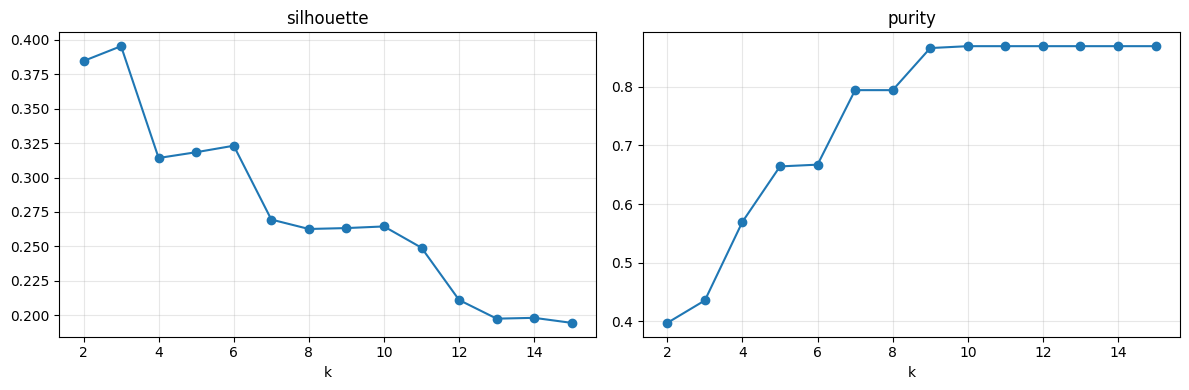

In [16]:
from sklearn.cluster import AgglomerativeClustering

ks = range(2, 16)
results_agg = []

for k in ks:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward').fit(X_scaled)
    results_agg.append({
        'k': k,
        'silhouette': silhouette_score(X_scaled, agg.labels_),
        'purity': purity_score(y_true, agg.labels_),
    })

res_agg = pd.DataFrame(results_agg)
print(res_agg.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['silhouette', 'purity']):
    ax.plot(res_agg['k'], res_agg[col], marker='o')
    ax.set_xlabel('k')
    ax.set_title(col)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

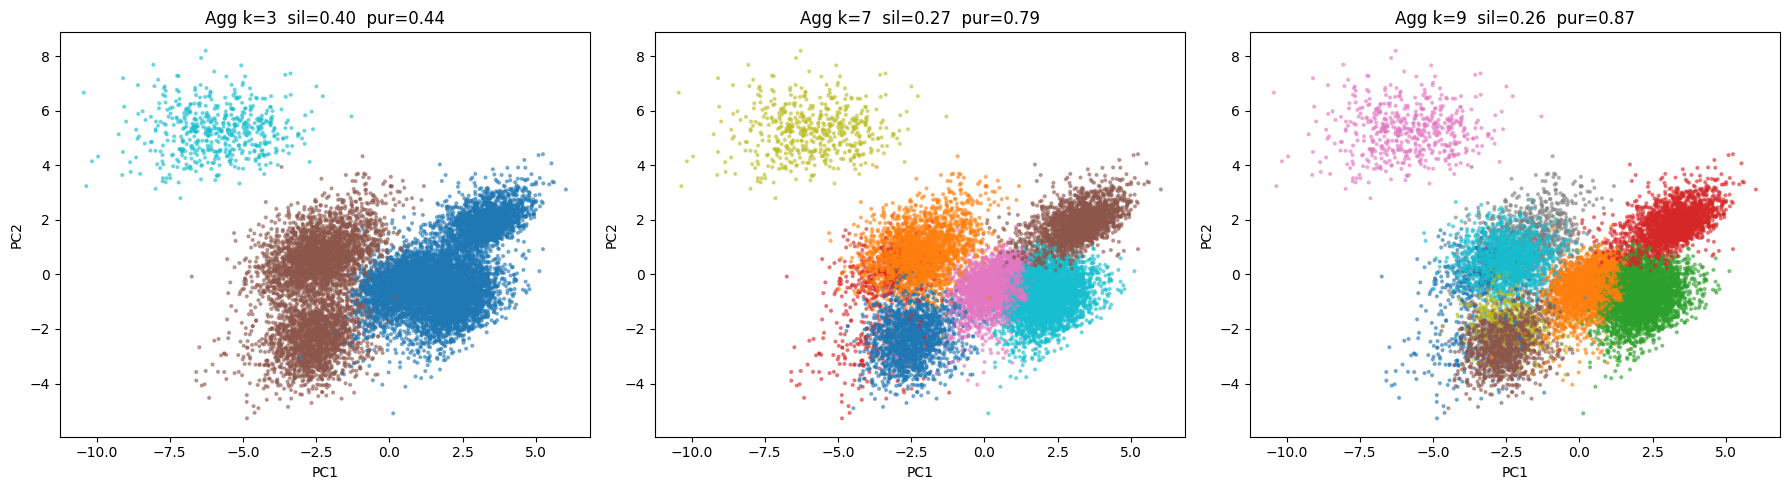

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, k in zip(axes, [3, 7, 9]):
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward').fit(X_scaled)
    sil = silhouette_score(X_scaled, agg.labels_)
    pur = purity_score(y_true, agg.labels_)
    show_clustering(agg.labels_, f'Agg k={k}  sil={sil:.2f}  pur={pur:.2f}', ax=ax)
plt.tight_layout()
plt.show()

### Wnioski z klasteryzacji

Silhouette jest najwyższe przy k=2 i k=3, bo tylko BOMBAY jest osobno, a reszta gatunków się zlewa. Przy większej liczbie klastrów spada poniżej 0.2

Purity rośnie z k i zatrzymuje się na 0.87 od k=10. Dalej dokładanie klastrów już nic nie poprawia.

Tak samo jak wcześniej: k=3 pokazuje naturalny podział danych, a k=7 do 9 najlepiej odtwarza gatunki.

## Porównanie

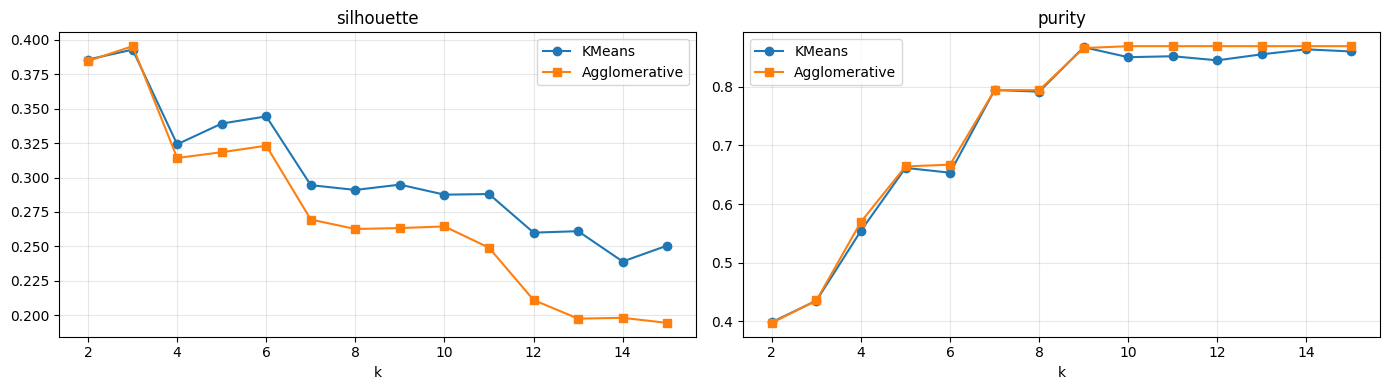

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['silhouette', 'purity']):
    ax.plot(res['k'], res[col], marker='o', label='KMeans')
    ax.plot(res_agg['k'], res_agg[col], marker='s', label='Agglomerative')
    ax.set_xlabel('k')
    ax.set_title(col)
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
import timeit

k = 7

def run_kmeans():
    KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)

def run_agg():
    AgglomerativeClustering(n_clusters=k, linkage='ward').fit(X_scaled)

n = 5
t_km = timeit.timeit(run_kmeans, number=n) / n
t_agg = timeit.timeit(run_agg, number=n) / n

print(f'KMeans:        {t_km:.3f} s')
print(f'Agglomerative: {t_agg:.3f} s')

KMeans:        1.550 s
Agglomerative: 5.760 s


**Metryki:** Purity jest prawie takie samo na całej długości, więc oba tak samo dobrze odtwarzają gatunki. Silhouette pokrywa się do k=6, a wyżej aglomeracyjna spada niżej, bo skleja grupy raz na zawsze i nie poprawia raz podjętych decyzji.

Obie metody pokazują podobny obraz (BOMBAY osobno, reszta zlana), czyli to prawdziwa cecha danych, a nie wynik jakiegoś algorytmu.

**Pomiar czasu:** aglomeracyjna jest prawie 4x wolniejsza. KMeans rośnie liniowo z liczbą ziaren, a aglomeracyjna musi liczyć odległości między wszystkimi parami, więc rośnie kwadratowo.